## MITSUI&CO Commodity Prediction - LSTM Model

In [4]:
# ============================================================
# CELL 1: Imports & Configuration
# ===============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
from scipy.stats import spearmanr
 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
 
warnings.filterwarnings("ignore")
 
# ── Paths (adjust these to your local setup) ──────────────────
DATA_PATH = Path("/Users/hayden/coderepos_mac_mini/mitsui_commodity/data")  # folder containing all CSVs
 
# ── Hyperparameters ───────────────────────────────────────────
SEQUENCE_LENGTH  = 20      # number of lookback days fed to LSTM
HIDDEN_SIZE      = 64      # LSTM hidden units
NUM_LAYERS       = 2       # stacked LSTM layers
DROPOUT          = 0.2
LEARNING_RATE    = 1e-3
EPOCHS           = 50
BATCH_SIZE       = 64
PATIENCE         = 10      # early stopping patience
VAL_SPLIT_DATE   = 1700    # train on dates < this, validate on dates >= this
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


In [6]:
# %% ============================================================
# CELL 2: Load Data
# ===============================================================
train        = pd.read_csv(DATA_PATH / "train.csv").sort_values("date_id").reset_index(drop=True)
train_labels = pd.read_csv(DATA_PATH / "train_labels.csv").sort_values("date_id").reset_index(drop=True)
test         = pd.read_csv(DATA_PATH / "test.csv").sort_values("date_id").reset_index(drop=True)
ground_truth = pd.read_csv(DATA_PATH / "test_ground_truth.csv").sort_values("date_id").reset_index(drop=True)
target_pairs = pd.read_csv(DATA_PATH / "target_pairs.csv")
 
# Drop non-feature columns from test
if "is_scored" in test.columns:
    is_scored = test["is_scored"].copy()
    test = test.drop(columns=["is_scored"])
 
# Feature & target column names
feature_cols = [c for c in train.columns if c != "date_id"]
target_cols  = [c for c in train_labels.columns if c != "date_id"]
 
print(f"Train features: {train.shape}")
print(f"Train labels:   {train_labels.shape}")
print(f"Test features:  {test.shape}")
print(f"Ground truth:   {ground_truth.shape}")
print(f"Features: {len(feature_cols)}, Targets: {len(target_cols)}")

Train features: (1961, 558)
Train labels:   (1961, 425)
Test features:  (134, 558)
Ground truth:   (134, 425)
Features: 557, Targets: 424


In [ ]:
# %% ============================================================
# CELL 3: Feature Engineering
# ===============================================================
def engineer_features(df: pd.DataFrame, feature_cols: list) -> pd.DataFrame:
    """
    Convert raw prices into returns and rolling statistics.
    Keeps date_id intact. Returns a new DataFrame.
    """
    feat = pd.DataFrame({"date_id": df["date_id"]})
 
    # ── 1-day returns for ALL price columns ───────────────────
    for col in feature_cols:
        feat[f"{col}_ret1"] = df[col].pct_change(1)
 
    # ── 5-day returns for a subset (control dimensionality) ───
    top_cols = feature_cols[:40]
    for col in top_cols:
        feat[f"{col}_ret5"] = df[col].pct_change(5)
 
    # ── 5-day rolling volatility for a subset ─────────────────
    for col in top_cols:
        feat[f"{col}_vol5"] = df[col].pct_change(1).rolling(5).std()
 
    # ── 20-day rolling mean return for a subset ───────────────
    for col in top_cols:
        feat[f"{col}_mom20"] = df[col].pct_change(1).rolling(20).mean()
 
    feat = feat.fillna(0.0)
    return feat
 
 
# Build features for the full date range
# Since train dates 0-1960 include test dates 1827-1960,
# we engineer on the full train set then slice for test
train_feat = engineer_features(train, feature_cols)
test_feat  = engineer_features(test, feature_cols)
 
eng_feature_cols = [c for c in train_feat.columns if c != "date_id"]
print(f"Engineered features: {len(eng_feature_cols)}")

Engineered features: 677


In [ ]:
# %% ============================================================
# CELL 4: Scale Features
# ===============================================================
scaler = StandardScaler()
 
# Fit scaler on training data only (dates < VAL_SPLIT_DATE)
train_mask = train_feat["date_id"] < VAL_SPLIT_DATE
scaler.fit(train_feat.loc[train_mask, eng_feature_cols])
 
# Transform both train and test
train_feat_scaled = scaler.transform(train_feat[eng_feature_cols])
test_feat_scaled  = scaler.transform(test_feat[eng_feature_cols])
 
# Prepare labels as numpy (keep NaNs — we'll mask them in the loss)
train_label_arr = train_labels[target_cols].values.astype(np.float32)
 
print(f"Scaled train features: {train_feat_scaled.shape}")
print(f"Scaled test features:  {test_feat_scaled.shape}")
print(f"Train labels array:    {train_label_arr.shape}")

Scaled train features: (1961, 677)
Scaled test features:  (134, 677)
Train labels array:    (1961, 424)


In [ ]:
# %% ============================================================
# CELL 5: Dataset & DataLoader
# ===============================================================
class CommodityDataset(Dataset):
    """Sliding-window dataset for LSTM."""
 
    def __init__(self, features: np.ndarray, targets: np.ndarray, seq_len: int):
        self.features = features.astype(np.float32)
        self.targets  = targets.astype(np.float32)
        self.seq_len  = seq_len
 
    def __len__(self):
        return len(self.features) - self.seq_len
 
    def __getitem__(self, idx):
        x = self.features[idx : idx + self.seq_len]       # (seq_len, n_features)
        y = self.targets[idx + self.seq_len]               # (n_targets,)
        return torch.from_numpy(x), torch.from_numpy(y)
 
 
# Split train into train / validation by date
val_start_idx = train_feat.loc[train_feat["date_id"] >= VAL_SPLIT_DATE].index[0]
 
train_ds = CommodityDataset(
    train_feat_scaled[:val_start_idx],
    train_label_arr[:val_start_idx],
    SEQUENCE_LENGTH
)
val_ds = CommodityDataset(
    train_feat_scaled[val_start_idx - SEQUENCE_LENGTH:],  # include lookback
    train_label_arr[val_start_idx - SEQUENCE_LENGTH:],
    SEQUENCE_LENGTH
)
 
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
 
print(f"Train samples: {len(train_ds)}, Val samples: {len(val_ds)}")

Train samples: 1680, Val samples: 261


In [ ]:
# %% ============================================================
# CELL 6: LSTM Model Definition
# ===============================================================
class LSTMPredictor(nn.Module):
    def __init__(self, n_features, n_targets, hidden_size=64,
                 num_layers=2, dropout=0.2):
        super().__init__()
 
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, n_targets),
        )
 
    def forward(self, x):
        # x: (batch, seq_len, n_features)
        lstm_out, _ = self.lstm(x)
        last = lstm_out[:, -1, :]     # last time-step hidden state
        return self.head(last)         # (batch, n_targets)
 
 
n_features = len(eng_feature_cols)
n_targets  = len(target_cols)
 
model = LSTMPredictor(
    n_features=n_features,
    n_targets=n_targets,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)
 
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(model)

Model parameters: 255,208
LSTMPredictor(
  (lstm): LSTM(677, 64, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=424, bias=True)
  )
)


In [ ]:
# %% ============================================================
# CELL 7: Training Loop
# ===============================================================
def masked_mse_loss(pred, target):
    """MSE loss that ignores NaN targets."""
    mask = ~torch.isnan(target)
    if mask.sum() == 0:
        return torch.tensor(0.0, device=pred.device, requires_grad=True)
    return nn.functional.mse_loss(pred[mask], target[mask])
 
 
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=PATIENCE // 2, factor=0.5
)
 
best_val_loss = float("inf")
best_state    = None
wait          = 0
history       = {"train_loss": [], "val_loss": []}
 
for epoch in range(EPOCHS):
    # ── Train ─────────────────────────────────────────────────
    model.train()
    epoch_train_losses = []
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
 
        pred = model(x_batch)
        loss = masked_mse_loss(pred, y_batch)
 
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
 
        epoch_train_losses.append(loss.item())
 
    # ── Validate ──────────────────────────────────────────────
    model.eval()
    epoch_val_losses = []
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            pred = model(x_batch)
            loss = masked_mse_loss(pred, y_batch)
            epoch_val_losses.append(loss.item())
 
    train_loss = np.mean(epoch_train_losses)
    val_loss   = np.mean(epoch_val_losses)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
 
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]
 
    # ── Early stopping ────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
        marker = " ★"
    else:
        wait += 1
        marker = ""
 
    if (epoch + 1) % 5 == 0 or marker:
        print(f"Epoch {epoch+1:3d}/{EPOCHS}  "
              f"train_loss={train_loss:.6f}  val_loss={val_loss:.6f}  "
              f"lr={current_lr:.1e}{marker}")
 
    if wait >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break
 
# Restore best model
model.load_state_dict(best_state)
model.to(DEVICE)
print(f"\nBest validation loss: {best_val_loss:.6f}")

Epoch   1/50  train_loss=0.004176  val_loss=0.001275  lr=1.0e-03 ★
Epoch   2/50  train_loss=0.001436  val_loss=0.000832  lr=1.0e-03 ★
Epoch   3/50  train_loss=0.001204  val_loss=0.000801  lr=1.0e-03 ★
Epoch   4/50  train_loss=0.001146  val_loss=0.000798  lr=1.0e-03 ★
Epoch   5/50  train_loss=0.001100  val_loss=0.000804  lr=1.0e-03
Epoch  10/50  train_loss=0.000893  val_loss=0.000834  lr=5.0e-04

Early stopping at epoch 14

Best validation loss: 0.000798


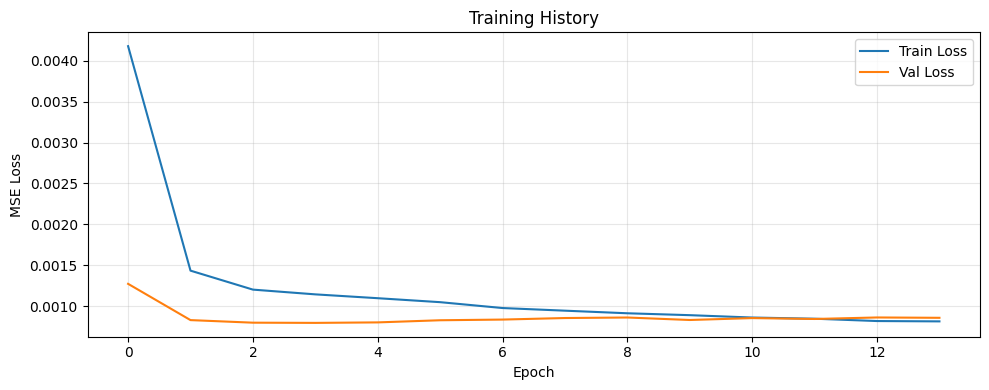

Saved training_history.png


In [ ]:
# %% ============================================================
# CELL 8: Plot Training History
# ===============================================================
plt.figure(figsize=(10, 4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"],   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training History")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_history.png", dpi=150)
plt.show()
print("Saved training_history.png")

In [ ]:
# %% ============================================================
# CELL 9: Generate Test Predictions
# ===============================================================
model.eval()
 
# Build sequences from test features
# Each prediction needs SEQUENCE_LENGTH prior rows
predictions = []
valid_test_indices = []
 
with torch.no_grad():
    for i in range(SEQUENCE_LENGTH, len(test_feat_scaled)):
        x = test_feat_scaled[i - SEQUENCE_LENGTH : i]
        x_tensor = torch.FloatTensor(x).unsqueeze(0).to(DEVICE)  # (1, seq, feat)
        pred = model(x_tensor).cpu().numpy()[0]                    # (n_targets,)
        predictions.append(pred)
        valid_test_indices.append(i)
 
predictions = np.array(predictions)
print(f"Generated predictions for {len(predictions)} test dates "
      f"(skipped first {SEQUENCE_LENGTH} for lookback)")
 
# Build predictions DataFrame aligned with ground truth
pred_df = pd.DataFrame(predictions, columns=target_cols)
pred_df.insert(0, "date_id", test.iloc[valid_test_indices]["date_id"].values)
 
# Align ground truth to same date range
gt_aligned = ground_truth[ground_truth["date_id"].isin(pred_df["date_id"])].reset_index(drop=True)
pred_aligned = pred_df[pred_df["date_id"].isin(gt_aligned["date_id"])].reset_index(drop=True)
 
print(f"Predictions shape: {pred_aligned.shape}")
print(f"Ground truth shape: {gt_aligned.shape}")

Generated predictions for 114 test dates (skipped first 20 for lookback)
Predictions shape: (114, 425)
Ground truth shape: (114, 425)


In [ ]:
# %% ============================================================
# CELL 10: Evaluate — Spearman Correlation (Competition Metric)
# ===============================================================
def evaluate_predictions(pred_df, gt_df, target_cols, target_pairs=None):
    """
    Compute per-target Spearman correlation and overall mean.
    Optionally break down by lag.
    """
    correlations = {}
 
    for col in target_cols:
        if col not in pred_df.columns or col not in gt_df.columns:
            continue
        mask = gt_df[col].notna()
        if mask.sum() < 5:
            continue
        corr, pval = spearmanr(pred_df.loc[mask, col], gt_df.loc[mask, col])
        correlations[col] = corr
 
    overall = np.nanmean(list(correlations.values()))
 
    print(f"{'='*50}")
    print(f"  Targets evaluated: {len(correlations)} / {len(target_cols)}")
    print(f"  Mean Spearman ρ:   {overall:.6f}")
    print(f"{'='*50}")
 
    # ── Breakdown by lag ──────────────────────────────────────
    if target_pairs is not None:
        print(f"\n  Per-lag breakdown:")
        for lag in sorted(target_pairs["lag"].unique()):
            lag_targets = target_pairs.loc[target_pairs["lag"] == lag, "target"].tolist()
            lag_corrs = [correlations[t] for t in lag_targets if t in correlations]
            if lag_corrs:
                print(f"    Lag {lag}: mean ρ = {np.nanmean(lag_corrs):.6f}  "
                      f"({len(lag_corrs)} targets)")
 
    return correlations, overall
 
 
correlations, overall_score = evaluate_predictions(
    pred_aligned, gt_aligned, target_cols, target_pairs
)

  Targets evaluated: 424 / 424
  Mean Spearman ρ:   0.009282

  Per-lag breakdown:
    Lag 1: mean ρ = 0.011072  (106 targets)
    Lag 2: mean ρ = 0.021396  (106 targets)
    Lag 3: mean ρ = 0.005830  (106 targets)
    Lag 4: mean ρ = -0.001168  (106 targets)


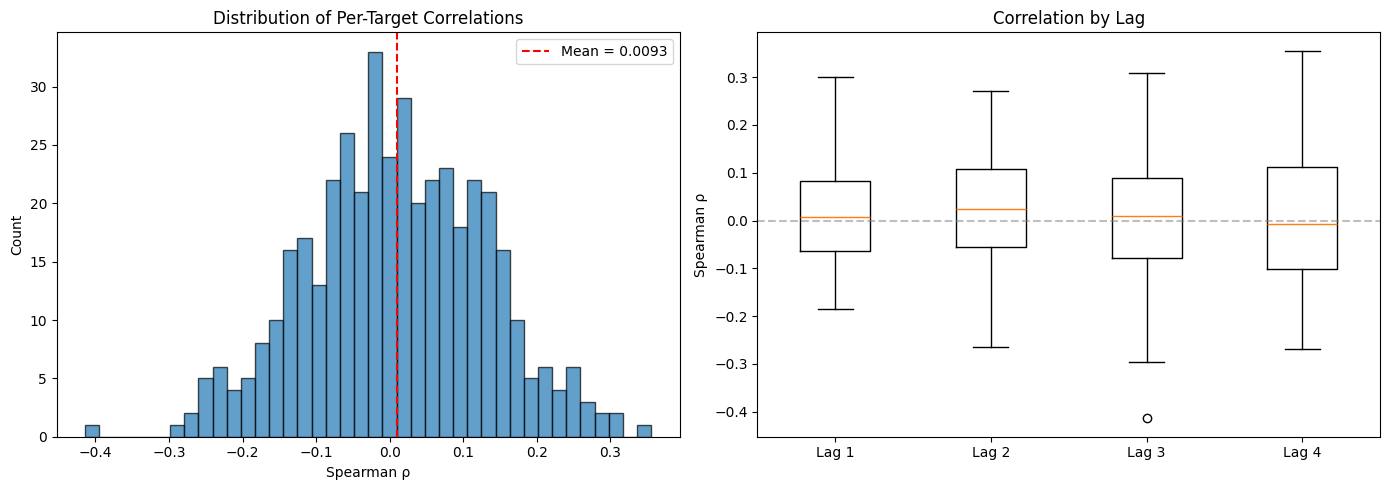

Saved evaluation_results.png


In [ ]:
# %% ============================================================
# CELL 11: Visualize Per-Target Performance
# ===============================================================
corr_values = list(correlations.values())
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Histogram of correlations
axes[0].hist(corr_values, bins=40, edgecolor="black", alpha=0.7)
axes[0].axvline(np.nanmean(corr_values), color="red", linestyle="--",
                label=f"Mean = {np.nanmean(corr_values):.4f}")
axes[0].set_xlabel("Spearman ρ")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Per-Target Correlations")
axes[0].legend()
 
# By lag
lag_data = []
for lag in [1, 2, 3, 4]:
    lag_targets = target_pairs.loc[target_pairs["lag"] == lag, "target"].tolist()
    lag_corrs = [correlations[t] for t in lag_targets if t in correlations]
    lag_data.append(lag_corrs)
 
axes[1].boxplot(lag_data, labels=["Lag 1", "Lag 2", "Lag 3", "Lag 4"])
axes[1].set_ylabel("Spearman ρ")
axes[1].set_title("Correlation by Lag")
axes[1].axhline(0, color="gray", linestyle="--", alpha=0.5)
 
plt.tight_layout()
plt.savefig("evaluation_results.png", dpi=150)
plt.show()
print("Saved evaluation_results.png")

In [ ]:
# %% ============================================================
# CELL 12: Save Predictions
# ===============================================================
pred_aligned.to_csv("predictions.csv", index=False)
print(f"Saved predictions.csv ({pred_aligned.shape})")
 
# Also save the full evaluation results
eval_df = pd.DataFrame([
    {"target": t, "spearman_rho": c,
     "lag": target_pairs.loc[target_pairs["target"] == t, "lag"].values[0]}
    for t, c in correlations.items()
])
eval_df.to_csv("evaluation_details.csv", index=False)
print(f"Saved evaluation_details.csv ({eval_df.shape})")
 
print(f"\n✓ Final score: mean Spearman ρ = {overall_score:.6f}")

## Hilariously bad baseline. .009 score against the ground truth. Time to tune things up.

# New attempt, using per-lag models, pair-aware features, and multi-horizon returns, multiseed ensemble, 

In [ ]:
# %% ============================================================
# CELL 1: Imports & Configuration
# ===============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import gc
import time
from pathlib import Path
from scipy.stats import spearmanr
 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import RobustScaler  # more robust to outliers than StandardScaler
 
warnings.filterwarnings("ignore")
 
# ── Paths ─────────────────────────────────────────────────────
DATA_PATH = Path("data")
 
# ── Hyperparameters ───────────────────────────────────────────
SEQUENCE_LENGTH  = 30       # lookback window
HIDDEN_SIZE      = 128      # LSTM hidden units
NUM_LAYERS       = 2        # stacked LSTM layers
DROPOUT          = 0.3
LEARNING_RATE    = 5e-4
WEIGHT_DECAY     = 1e-4     # L2 regularization
EPOCHS           = 80
BATCH_SIZE       = 32
PATIENCE         = 15       # early stopping patience
VAL_SPLIT_DATE   = 1700     # train < this, validate >= this
N_SEEDS          = 3        # ensemble over multiple seeds
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
# %% ============================================================
# CELL 2: Load Data
# ===============================================================
train        = pd.read_csv(DATA_PATH / "train.csv").sort_values("date_id").reset_index(drop=True)
train_labels = pd.read_csv(DATA_PATH / "train_labels.csv").sort_values("date_id").reset_index(drop=True)
test         = pd.read_csv(DATA_PATH / "test.csv").sort_values("date_id").reset_index(drop=True)
ground_truth = pd.read_csv(DATA_PATH / "test_ground_truth.csv").sort_values("date_id").reset_index(drop=True)
target_pairs = pd.read_csv(DATA_PATH / "target_pairs.csv")
 
if "is_scored" in test.columns:
    is_scored = test["is_scored"].copy()
    test = test.drop(columns=["is_scored"])
 
feature_cols = [c for c in train.columns if c != "date_id"]
target_cols  = [c for c in train_labels.columns if c != "date_id"]
 
# Group targets by lag
lag_groups = {}
for lag in [1, 2, 3, 4]:
    lag_targets = target_pairs.loc[target_pairs["lag"] == lag, "target"].tolist()
    lag_groups[lag] = lag_targets
 
print(f"Train: {train.shape}, Test: {test.shape}")
print(f"Features: {len(feature_cols)}, Targets: {len(target_cols)}")
for lag, targets in lag_groups.items():
    print(f"  Lag {lag}: {len(targets)} targets ({targets[0]}..{targets[-1]})")

Train: (1961, 558), Test: (134, 558)
Features: 557, Targets: 424
  Lag 1: 106 targets (target_0..target_105)
  Lag 2: 106 targets (target_106..target_211)
  Lag 3: 106 targets (target_212..target_317)
  Lag 4: 106 targets (target_318..target_423)


In [ ]:
# %% ============================================================
# CELL 3: Pair-Aware Feature Engineering
# ===============================================================
def find_related_columns(asset_name: str, all_columns: list) -> list:
    """Find all OHLCV columns related to an asset."""
    # For 'US_Stock_VT_adj_close' -> find all 'US_Stock_VT_adj_*'
    # For 'LME_AH_Close' -> find all 'LME_AH_*'
    # For 'FX_AUDJPY' -> just 'FX_AUDJPY'
 
    if "_adj_" in asset_name:
        base = asset_name.rsplit("_", 1)[0]  # US_Stock_VT_adj
    elif asset_name.startswith("FX_"):
        base = asset_name
    elif "_Close" in asset_name:
        base = asset_name.rsplit("_", 1)[0]  # LME_AH
    elif "_Futures_Close" in asset_name:
        base = asset_name.rsplit("_Close", 1)[0]
    else:
        base = asset_name
 
    related = [c for c in all_columns if c.startswith(base) or c == asset_name]
    return list(set(related))
 
 
def get_pair_assets(pair_str: str):
    """Parse pair string into (asset_a, asset_b) or (asset_a, None)."""
    if " - " in pair_str:
        a, b = pair_str.split(" - ", 1)
        return a.strip(), b.strip()
    return pair_str.strip(), None
 
 
def engineer_global_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build a rich feature set from raw prices.
    Returns DataFrame with date_id + engineered features.
    """
    feat = pd.DataFrame({"date_id": df["date_id"].values})
    price_cols = [c for c in df.columns if c != "date_id"]
 
    # ── Identify the 106 target assets (the ones that appear in pairs) ──
    all_assets = set()
    for _, row in target_pairs.iterrows():
        a, b = get_pair_assets(row["pair"])
        all_assets.add(a)
        if b:
            all_assets.add(b)
    target_assets = [c for c in all_assets if c in df.columns]
 
    # ── Multi-horizon returns for all target assets ───────────
    for col in target_assets:
        prices = df[col]
        for horizon in [1, 2, 3, 5, 10, 20]:
            feat[f"{col}_ret{horizon}"] = prices.pct_change(horizon)
 
    # ── Rolling statistics for target assets ──────────────────
    for col in target_assets:
        ret1 = df[col].pct_change(1)
        for window in [5, 10, 20]:
            feat[f"{col}_vol{window}"] = ret1.rolling(window).std()
            feat[f"{col}_mom{window}"] = ret1.rolling(window).mean()
 
        # RSI-like feature (ratio of up days to total in window)
        up = (ret1 > 0).astype(float)
        feat[f"{col}_upratio10"] = up.rolling(10).mean()
 
    # ── Pair-specific features ────────────────────────────────
    pairs_done = set()
    for _, row in target_pairs.iterrows():
        a, b = get_pair_assets(row["pair"])
        if b is None:
            continue
        pair_key = f"{a}__{b}"
        if pair_key in pairs_done:
            continue
        pairs_done.add(pair_key)
 
        if a not in df.columns or b not in df.columns:
            continue
 
        pa, pb = df[a], df[b]
 
        # Spread and ratio
        feat[f"{pair_key}_spread"] = pa - pb
        feat[f"{pair_key}_ratio"] = pa / pb.replace(0, np.nan)
 
        # Spread return
        spread = pa - pb
        feat[f"{pair_key}_spread_ret1"] = spread.pct_change(1)
        feat[f"{pair_key}_spread_ret5"] = spread.pct_change(5)
 
        # Relative momentum (difference in returns)
        feat[f"{pair_key}_relmom5"] = pa.pct_change(5) - pb.pct_change(5)
        feat[f"{pair_key}_relmom20"] = pa.pct_change(20) - pb.pct_change(20)
 
        # Rolling correlation between the two assets
        ret_a = pa.pct_change(1)
        ret_b = pb.pct_change(1)
        feat[f"{pair_key}_corr20"] = ret_a.rolling(20).corr(ret_b)
 
    # ── OHLCV features for US stocks (have full OHLCV) ────────
    for col in target_assets:
        if "_adj_close" in col:
            base = col.replace("_close", "")
            high_col = f"{base}_high"
            low_col = f"{base}_low"
            vol_col = f"{base}_volume"
 
            if high_col in df.columns and low_col in df.columns:
                # Intraday range
                feat[f"{col}_range"] = (df[high_col] - df[low_col]) / df[col].replace(0, np.nan)
 
            if vol_col in df.columns:
                # Volume change
                feat[f"{col}_volchg"] = df[vol_col].pct_change(1)
                feat[f"{col}_volavg5"] = df[vol_col].rolling(5).mean()
 
    # ── Replace inf and fill NaN ──────────────────────────────
    feat = feat.replace([np.inf, -np.inf], np.nan)
    feat = feat.fillna(0.0)
 
    return feat
 
 
print("Engineering features (this may take a minute)...")
t0 = time.time()
train_feat = engineer_global_features(train)
test_feat  = engineer_global_features(test)
print(f"Done in {time.time()-t0:.1f}s")
 
eng_feature_cols = [c for c in train_feat.columns if c != "date_id"]
print(f"Engineered features: {len(eng_feature_cols)}")

Engineering features (this may take a minute)...
Done in 6.5s
Engineered features: 4169


In [ ]:
# %% ============================================================
# CELL 4: Scale Features
# ===============================================================
# RobustScaler handles financial outliers better than StandardScaler
scaler = RobustScaler()
 
train_mask = train_feat["date_id"] < VAL_SPLIT_DATE
scaler.fit(train_feat.loc[train_mask, eng_feature_cols])
 
train_feat_scaled = scaler.transform(train_feat[eng_feature_cols]).astype(np.float32)
test_feat_scaled  = scaler.transform(test_feat[eng_feature_cols]).astype(np.float32)
 
# Clip extreme values after scaling (financial data has fat tails)
train_feat_scaled = np.clip(train_feat_scaled, -5, 5)
test_feat_scaled  = np.clip(test_feat_scaled, -5, 5)
 
train_label_arr = train_labels[target_cols].values.astype(np.float32)
 
print(f"Scaled train: {train_feat_scaled.shape}")
print(f"Scaled test:  {test_feat_scaled.shape}")

Scaled train: (1961, 4169)
Scaled test:  (134, 4169)


In [ ]:
# %% ============================================================
# CELL 5: Dataset
# ===============================================================
class CommodityDataset(Dataset):
    """Sliding-window dataset. Can target a subset of columns (for per-lag training)."""
 
    def __init__(self, features: np.ndarray, targets: np.ndarray,
                 seq_len: int, target_indices: list = None):
        self.features = features
        self.seq_len  = seq_len
 
        if target_indices is not None:
            self.targets = targets[:, target_indices]
        else:
            self.targets = targets
 
    def __len__(self):
        return len(self.features) - self.seq_len
 
    def __getitem__(self, idx):
        x = self.features[idx : idx + self.seq_len]
        y = self.targets[idx + self.seq_len]
        return torch.from_numpy(x), torch.from_numpy(y)

In [ ]:
# %% ============================================================
# CELL 6: Improved LSTM Model with Attention
# ===============================================================
class TemporalAttention(nn.Module):
    """Attention over LSTM time steps — lets the model focus on important days."""
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1),
        )
 
    def forward(self, lstm_output):
        # lstm_output: (batch, seq_len, hidden)
        scores = self.attn(lstm_output).squeeze(-1)          # (batch, seq_len)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)  # (batch, seq_len, 1)
        context = (lstm_output * weights).sum(dim=1)           # (batch, hidden)
        return context, weights.squeeze(-1)
 
 
class ImprovedLSTM(nn.Module):
    def __init__(self, n_features, n_targets, hidden_size=128,
                 num_layers=2, dropout=0.3, bidirectional=True):
        super().__init__()
 
        self.bidirectional = bidirectional
        dir_mult = 2 if bidirectional else 1
 
        # Input projection (helps with high-dimensional features)
        self.input_proj = nn.Sequential(
            nn.Linear(n_features, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
 
        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
 
        self.attention = TemporalAttention(hidden_size * dir_mult)
        self.layer_norm = nn.LayerNorm(hidden_size * dir_mult)
 
        self.head = nn.Sequential(
            nn.Linear(hidden_size * dir_mult, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden_size // 2, n_targets),
        )
 
    def forward(self, x):
        # x: (batch, seq_len, n_features)
        x = self.input_proj(x)              # (batch, seq_len, hidden)
        lstm_out, _ = self.lstm(x)          # (batch, seq_len, hidden * dir)
        context, attn_w = self.attention(lstm_out)
        context = self.layer_norm(context)
        return self.head(context)

In [ ]:
# %% ============================================================
# CELL 7: Training Function (reusable per lag)
# ===============================================================
def masked_mse_loss(pred, target):
    """MSE that ignores NaN targets."""
    mask = ~torch.isnan(target)
    if mask.sum() == 0:
        return torch.tensor(0.0, device=pred.device, requires_grad=True)
    return nn.functional.mse_loss(pred[mask], target[mask])
 
 
def train_one_model(model, train_loader, val_loader, epochs, lr,
                    weight_decay, patience, device, label=""):
    """Full training loop with cosine annealing and early stopping."""
 
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
 
    # Cosine annealing with warm restarts
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=20, T_mult=2, eta_min=1e-6
    )
 
    best_val_loss = float("inf")
    best_state = None
    wait = 0
    history = {"train_loss": [], "val_loss": []}
 
    for epoch in range(epochs):
        # ── Train ─────────────────────────────────────────────
        model.train()
        train_losses = []
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            pred = model(x_batch)
            loss = masked_mse_loss(pred, y_batch)
 
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())
 
        scheduler.step()
 
        # ── Validate ──────────────────────────────────────────
        model.eval()
        val_losses = []
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                pred = model(x_batch)
                loss = masked_mse_loss(pred, y_batch)
                val_losses.append(loss.item())
 
        train_loss = np.mean(train_losses)
        val_loss   = np.mean(val_losses) if val_losses else float("inf")
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
 
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
            marker = " ★"
        else:
            wait += 1
            marker = ""
 
        if (epoch + 1) % 10 == 0 or marker:
            lr_now = optimizer.param_groups[0]["lr"]
            print(f"  [{label}] Epoch {epoch+1:3d}/{epochs}  "
                  f"train={train_loss:.6f}  val={val_loss:.6f}  "
                  f"lr={lr_now:.1e}{marker}")
 
        if wait >= patience:
            print(f"  [{label}] Early stopping at epoch {epoch+1}")
            break
 
    model.load_state_dict(best_state)
    model.to(device)
    return model, history

In [ ]:
# %% ============================================================
# CELL 8: Train Per-Lag Models with Multi-Seed Ensemble
# ===============================================================
val_start_idx = train_feat[train_feat["date_id"] >= VAL_SPLIT_DATE].index[0]
 
# Store all models: {lag: [model_seed0, model_seed1, ...]}
all_models = {lag: [] for lag in [1, 2, 3, 4]}
all_histories = {lag: [] for lag in [1, 2, 3, 4]}
 
for lag in [1, 2, 3, 4]:
    lag_target_names = lag_groups[lag]
    # Map target names to column indices in train_label_arr
    lag_target_indices = [target_cols.index(t) for t in lag_target_names]
    n_lag_targets = len(lag_target_indices)
 
    print(f"\n{'='*60}")
    print(f"Training Lag {lag} model ({n_lag_targets} targets)")
    print(f"{'='*60}")
 
    for seed_idx in range(N_SEEDS):
        seed = 42 + seed_idx * 111
        torch.manual_seed(seed)
        np.random.seed(seed)
 
        print(f"\n  Seed {seed_idx+1}/{N_SEEDS} (seed={seed})")
 
        # Build datasets for this lag
        train_ds = CommodityDataset(
            train_feat_scaled[:val_start_idx],
            train_label_arr[:val_start_idx],
            SEQUENCE_LENGTH,
            target_indices=lag_target_indices,
        )
        val_ds = CommodityDataset(
            train_feat_scaled[val_start_idx - SEQUENCE_LENGTH:],
            train_label_arr[val_start_idx - SEQUENCE_LENGTH:],
            SEQUENCE_LENGTH,
            target_indices=lag_target_indices,
        )
 
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                                  shuffle=True, drop_last=True)
        val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE,
                                  shuffle=False, drop_last=False)
 
        # Create model
        model = ImprovedLSTM(
            n_features=len(eng_feature_cols),
            n_targets=n_lag_targets,
            hidden_size=HIDDEN_SIZE,
            num_layers=NUM_LAYERS,
            dropout=DROPOUT,
            bidirectional=True,
        ).to(DEVICE)
 
        if seed_idx == 0:
            n_params = sum(p.numel() for p in model.parameters())
            print(f"  Model parameters: {n_params:,}")
 
        model, history = train_one_model(
            model, train_loader, val_loader,
            epochs=EPOCHS, lr=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY, patience=PATIENCE,
            device=DEVICE, label=f"Lag{lag}-s{seed_idx}",
        )
 
        all_models[lag].append(model)
        all_histories[lag].append(history)
 
    gc.collect()
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
 
print(f"\n{'='*60}")
print(f"Training complete! {sum(len(v) for v in all_models.values())} models total")


Training Lag 1 model (106 targets)

  Seed 1/3 (seed=42)
  Model parameters: 1,275,051
  [Lag1-s0] Epoch   1/80  train=0.002472  val=0.000457  lr=5.0e-04 ★
  [Lag1-s0] Epoch   2/80  train=0.000790  val=0.000415  lr=4.9e-04 ★
  [Lag1-s0] Epoch   3/80  train=0.000671  val=0.000412  lr=4.7e-04 ★
  [Lag1-s0] Epoch   4/80  train=0.000612  val=0.000378  lr=4.5e-04 ★
  [Lag1-s0] Epoch   8/80  train=0.000528  val=0.000372  lr=3.3e-04 ★
  [Lag1-s0] Epoch  10/80  train=0.000515  val=0.000384  lr=2.5e-04
  [Lag1-s0] Epoch  13/80  train=0.000490  val=0.000371  lr=1.4e-04 ★
  [Lag1-s0] Epoch  15/80  train=0.000492  val=0.000371  lr=7.4e-05 ★
  [Lag1-s0] Epoch  16/80  train=0.000491  val=0.000370  lr=4.9e-05 ★
  [Lag1-s0] Epoch  20/80  train=0.000490  val=0.000370  lr=5.0e-04
  [Lag1-s0] Epoch  30/80  train=0.000467  val=0.000377  lr=4.3e-04
  [Lag1-s0] Early stopping at epoch 31

  Seed 2/3 (seed=153)
  [Lag1-s1] Epoch   1/80  train=0.002471  val=0.000421  lr=5.0e-04 ★
  [Lag1-s1] Epoch   2/80  tr

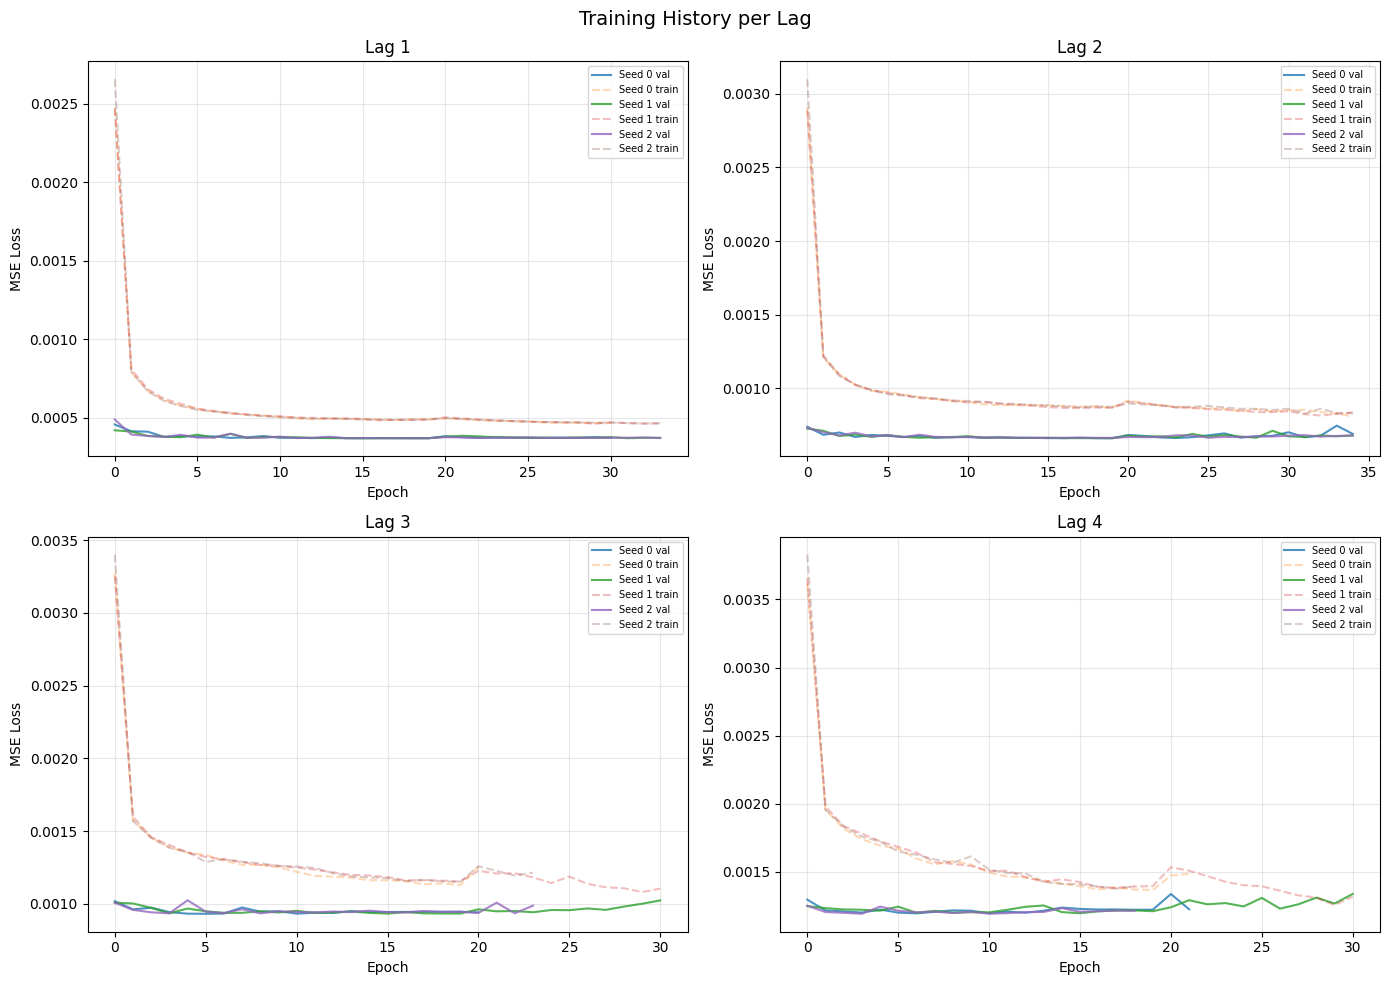

In [ ]:
# %% ============================================================
# CELL 9: Plot Training Histories
# ===============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, lag in enumerate([1, 2, 3, 4]):
    ax = axes[idx // 2][idx % 2]
    for s, hist in enumerate(all_histories[lag]):
        ax.plot(hist["val_loss"], label=f"Seed {s} val", alpha=0.8)
        ax.plot(hist["train_loss"], label=f"Seed {s} train", alpha=0.3, linestyle="--")
    ax.set_title(f"Lag {lag}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
 
plt.suptitle("Training History per Lag", fontsize=14)
plt.tight_layout()
plt.savefig("training_history_v2.png", dpi=150)
plt.show()

In [ ]:
# %% ============================================================
# CELL 10: Generate Predictions (Ensemble Averaged)
# ===============================================================
def predict_lag(models, features, seq_len, device):
    """Generate predictions averaged across seed ensemble."""
    all_preds = []
 
    for model in models:
        model.eval()
        preds = []
        with torch.no_grad():
            for i in range(seq_len, len(features)):
                x = features[i - seq_len : i]
                x_t = torch.FloatTensor(x).unsqueeze(0).to(device)
                pred = model(x_t).cpu().numpy()[0]
                preds.append(pred)
        all_preds.append(np.array(preds))
 
    # Average across seeds
    ensemble_pred = np.mean(all_preds, axis=0)
    return ensemble_pred
 
 
print("Generating predictions...")
valid_test_indices = list(range(SEQUENCE_LENGTH, len(test_feat_scaled)))
valid_date_ids = test.iloc[valid_test_indices]["date_id"].values
 
# Predict per lag, assemble into full prediction
full_predictions = np.zeros((len(valid_test_indices), len(target_cols)))
 
for lag in [1, 2, 3, 4]:
    print(f"  Predicting lag {lag}...")
    lag_preds = predict_lag(all_models[lag], test_feat_scaled, SEQUENCE_LENGTH, DEVICE)
 
    lag_target_names = lag_groups[lag]
    lag_target_indices = [target_cols.index(t) for t in lag_target_names]
 
    full_predictions[:, lag_target_indices] = lag_preds
 
# Build predictions DataFrame
pred_df = pd.DataFrame(full_predictions, columns=target_cols)
pred_df.insert(0, "date_id", valid_date_ids)
 
print(f"Predictions shape: {pred_df.shape}")

Generating predictions...
  Predicting lag 1...
  Predicting lag 2...
  Predicting lag 3...
  Predicting lag 4...
Predictions shape: (104, 425)


In [ ]:
# %% ============================================================
# CELL 11: Evaluate Against Ground Truth
# ===============================================================
def evaluate(pred_df, gt_df, target_cols, target_pairs_df=None,
             scored_dates=None):
    """
    Spearman correlation evaluation with optional filtering
    to only scored dates.
    """
    # Align on date_id
    common_dates = set(pred_df["date_id"]) & set(gt_df["date_id"])
    if scored_dates is not None:
        common_dates = common_dates & set(scored_dates)
 
    pred = pred_df[pred_df["date_id"].isin(common_dates)].sort_values("date_id").reset_index(drop=True)
    gt   = gt_df[gt_df["date_id"].isin(common_dates)].sort_values("date_id").reset_index(drop=True)
 
    correlations = {}
    for col in target_cols:
        if col not in pred.columns or col not in gt.columns:
            continue
        mask = gt[col].notna()
        if mask.sum() < 5:
            continue
        corr, _ = spearmanr(pred.loc[mask, col], gt.loc[mask, col])
        correlations[col] = corr
 
    overall = np.nanmean(list(correlations.values()))
 
    print(f"\n{'='*55}")
    print(f"  Dates evaluated:   {len(common_dates)}")
    print(f"  Targets evaluated: {len(correlations)} / {len(target_cols)}")
    print(f"  Mean Spearman ρ:   {overall:.6f}")
    print(f"{'='*55}")
 
    if target_pairs_df is not None:
        print(f"\n  Per-lag breakdown:")
        for lag in sorted(target_pairs_df["lag"].unique()):
            lag_targets = target_pairs_df.loc[
                target_pairs_df["lag"] == lag, "target"
            ].tolist()
            lag_corrs = [correlations[t] for t in lag_targets if t in correlations]
            if lag_corrs:
                mean_c = np.nanmean(lag_corrs)
                med_c  = np.nanmedian(lag_corrs)
                pos    = sum(1 for c in lag_corrs if c > 0)
                print(f"    Lag {lag}: mean={mean_c:.6f}  median={med_c:.6f}  "
                      f"positive={pos}/{len(lag_corrs)}")
 
    return correlations, overall
 
 
# Evaluate on all dates
print("Evaluation on ALL test dates:")
correlations, overall = evaluate(pred_df, ground_truth, target_cols, target_pairs)
 
# Evaluate on scored dates only
print("\nEvaluation on SCORED dates only:")
scored_dates = test.loc[is_scored, "date_id"].values
corr_scored, overall_scored = evaluate(
    pred_df, ground_truth, target_cols, target_pairs, scored_dates
)

Evaluation on ALL test dates:

  Dates evaluated:   104
  Targets evaluated: 424 / 424
  Mean Spearman ρ:   0.007751

  Per-lag breakdown:
    Lag 1: mean=0.011034  median=0.016642  positive=60/106
    Lag 2: mean=-0.004708  median=-0.003481  positive=51/106
    Lag 3: mean=0.023418  median=0.047892  positive=61/106
    Lag 4: mean=0.001262  median=-0.003166  positive=53/106

Evaluation on SCORED dates only:

  Dates evaluated:   60
  Targets evaluated: 424 / 424
  Mean Spearman ρ:   0.040781

  Per-lag breakdown:
    Lag 1: mean=0.045869  median=0.031385  positive=64/106
    Lag 2: mean=0.020347  median=0.007539  positive=55/106
    Lag 3: mean=0.064437  median=0.074519  positive=69/106
    Lag 4: mean=0.032472  median=0.030608  positive=57/106


In [ ]:
# %% ============================================================
# CELL 12: Visualize Results
# ===============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
# Distribution of correlations
corr_vals = list(correlations.values())
axes[0].hist(corr_vals, bins=50, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].axvline(np.nanmean(corr_vals), color="red", linestyle="--",
                label=f"Mean = {np.nanmean(corr_vals):.4f}")
axes[0].axvline(0, color="gray", linestyle="-", alpha=0.5)
axes[0].set_xlabel("Spearman ρ")
axes[0].set_ylabel("Count")
axes[0].set_title("Per-Target Correlation Distribution")
axes[0].legend()
 
# Box plot by lag
lag_data = []
for lag in [1, 2, 3, 4]:
    lag_targets = target_pairs.loc[target_pairs["lag"] == lag, "target"].tolist()
    lag_corrs = [correlations[t] for t in lag_targets if t in correlations]
    lag_data.append(lag_corrs)
bp = axes[1].boxplot(lag_data, labels=["Lag 1", "Lag 2", "Lag 3", "Lag 4"],
                     patch_artist=True)
colors = ["#3498db", "#2ecc71", "#e74c3c", "#9b59b6"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[1].set_ylabel("Spearman ρ")
axes[1].set_title("Correlation by Lag")
 
# Top and bottom targets
sorted_corrs = sorted(correlations.items(), key=lambda x: x[1], reverse=True)
top_10 = sorted_corrs[:10]
bot_10 = sorted_corrs[-10:]
show = bot_10[::-1] + top_10[::-1]
names = [f"{t} ({target_pairs.loc[target_pairs['target']==t, 'pair'].values[0][:25]})" 
         for t, _ in show]
vals = [c for _, c in show]
colors_bar = ["#e74c3c" if v < 0 else "#2ecc71" for v in vals]
axes[2].barh(range(len(show)), vals, color=colors_bar, alpha=0.7)
axes[2].set_yticks(range(len(show)))
axes[2].set_yticklabels(names, fontsize=7)
axes[2].axvline(0, color="gray", linestyle="-")
axes[2].set_xlabel("Spearman ρ")
axes[2].set_title("Top 10 & Bottom 10 Targets")
 
plt.tight_layout()
plt.savefig("evaluation_v2.png", dpi=150)
plt.show()

In [ ]:
# %% ============================================================
# CELL 13: Save Outputs
# ===============================================================
# Save predictions
pred_df.to_csv("predictions_lstm_v2.csv", index=False)
 
# Save detailed evaluation
eval_rows = []
for t, c in correlations.items():
    row = target_pairs.loc[target_pairs["target"] == t].iloc[0]
    eval_rows.append({
        "target": t, "pair": row["pair"], "lag": row["lag"],
        "spearman_rho": c,
    })
eval_df = pd.DataFrame(eval_rows).sort_values("spearman_rho", ascending=False)
eval_df.to_csv("evaluation_details_v2.csv", index=False)
 
# Save models
for lag in [1, 2, 3, 4]:
    for s, model in enumerate(all_models[lag]):
        torch.save(model.state_dict(), f"model_lag{lag}_seed{s}.pt")
 
print(f"Saved predictions, evaluation details, and {N_SEEDS * 4} model files")
print(f"\nFinal score (all dates):    {overall:.6f}")
print(f"Final score (scored only):  {overall_scored:.6f}")

In [ ]:
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr
import numpy as np

X = train[feature_cols].pct_change(1).fillna(0)
y_all = train_labels[target_cols]

val_mask = train["date_id"] >= 1700
train_mask = train["date_id"] < 1700

corrs = []
for col in target_cols[:50]:  # test first 50 targets
    mask = y_all[col].notna() & train_mask
    mask_v = y_all[col].notna() & val_mask
    if mask.sum() < 50 or mask_v.sum() < 10:
        continue
    m = Ridge(alpha=10.0)
    m.fit(X.loc[mask], y_all.loc[mask, col])
    pred = m.predict(X.loc[mask_v])
    c, _ = spearmanr(pred, y_all.loc[mask_v, col])
    corrs.append(c)

print(f"Ridge baseline on 50 targets: mean Spearman = {np.mean(corrs):.4f}")

Ridge baseline on 50 targets: mean Spearman = 0.0065


In [ ]:
corrs2 = []
for col in target_cols[:50]:
    pair_info = target_pairs[target_pairs["target"] == col].iloc[0]
    pair_str = pair_info["pair"]
    
    # Get just the assets in this pair
    if " - " in pair_str:
        a, b = pair_str.split(" - ")
        pair_feats = [c for c in feature_cols if a.split("_adj")[0].split("_Close")[0] in c 
                      or b.split("_adj")[0].split("_Close")[0] in c]
    else:
        pair_feats = [c for c in feature_cols if pair_str.split("_adj")[0].split("_Close")[0] in c]
    
    if len(pair_feats) == 0:
        continue
        
    X_pair = train[pair_feats].pct_change(1).fillna(0)
    mask = y_all[col].notna() & train_mask
    mask_v = y_all[col].notna() & val_mask
    if mask.sum() < 50 or mask_v.sum() < 10:
        continue
    
    m = Ridge(alpha=1.0)
    m.fit(X_pair.loc[mask], y_all.loc[mask, col])
    pred = m.predict(X_pair.loc[mask_v])
    c, _ = spearmanr(pred, y_all.loc[mask_v, col])
    corrs2.append(c)

print(f"Targeted Ridge (pair-only features): mean Spearman = {np.mean(corrs2):.4f}")

Targeted Ridge (pair-only features): mean Spearman = 0.0010


In [ ]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

X = train[feature_cols].pct_change(1).fillna(0)

corrs3 = []
for n_comp in [10, 30, 50, 100]:
    target_corrs = []
    for col in target_cols[:50]:
        mask = y_all[col].notna() & train_mask
        mask_v = y_all[col].notna() & val_mask
        if mask.sum() < 50 or mask_v.sum() < 10:
            continue
        
        pipe = Pipeline([
            ("pca", PCA(n_components=n_comp)),
            ("ridge", Ridge(alpha=10.0))
        ])
        pipe.fit(X.loc[mask], y_all.loc[mask, col])
        pred = pipe.predict(X.loc[mask_v])
        c, _ = spearmanr(pred, y_all.loc[mask_v, col])
        target_corrs.append(c)
    
    mean_c = np.mean(target_corrs)
    corrs3.append((n_comp, mean_c))
    print(f"PCA({n_comp:3d}) + Ridge: mean Spearman = {mean_c:.4f}")

PCA( 10) + Ridge: mean Spearman = 0.0061
PCA( 30) + Ridge: mean Spearman = 0.0154
PCA( 50) + Ridge: mean Spearman = 0.0106
PCA(100) + Ridge: mean Spearman = 0.0270


In [ ]:
for n_comp in [150, 200, 300, 400]:
    target_corrs = []
    for col in target_cols[:50]:
        mask = y_all[col].notna() & train_mask
        mask_v = y_all[col].notna() & val_mask
        if mask.sum() < 50 or mask_v.sum() < 10:
            continue
        
        pipe = Pipeline([
            ("pca", PCA(n_components=n_comp)),
            ("ridge", Ridge(alpha=10.0))
        ])
        pipe.fit(X.loc[mask], y_all.loc[mask, col])
        pred = pipe.predict(X.loc[mask_v])
        c, _ = spearmanr(pred, y_all.loc[mask_v, col])
        target_corrs.append(c)
    
    mean_c = np.mean(target_corrs)
    print(f"PCA({n_comp:3d}) + Ridge: mean Spearman = {mean_c:.4f}")

PCA(150) + Ridge: mean Spearman = 0.0077
PCA(200) + Ridge: mean Spearman = 0.0070
PCA(300) + Ridge: mean Spearman = 0.0066
PCA(400) + Ridge: mean Spearman = 0.0065


In [ ]:
def competition_score(pred_df, gt_df, target_cols):
    """Exact replication of the Kaggle grading metric."""
    pred = pred_df[target_cols].copy()
    gt = gt_df[target_cols].copy()
    
    daily_corrs = []
    for i in range(len(pred)):
        gt_row = gt.iloc[i]
        pred_row = pred.iloc[i]
        
        # Only use non-null targets
        valid = gt_row.notna()
        if valid.sum() < 2:
            continue
        
        gt_valid = gt_row[valid]
        pred_valid = pred_row[valid]
        
        # Check for zero std
        if gt_valid.std(ddof=0) == 0 or pred_valid.std(ddof=0) == 0:
            continue
        
        corr = np.corrcoef(
            pred_valid.rank(method='average'),
            gt_valid.rank(method='average')
        )[0, 1]
        daily_corrs.append(corr)
    
    daily_corrs = np.array(daily_corrs)
    sharpe = daily_corrs.mean() / daily_corrs.std(ddof=0)
    
    print(f"  Daily rank correlations: mean={daily_corrs.mean():.6f}, std={daily_corrs.std():.6f}")
    print(f"  Days evaluated: {len(daily_corrs)}")
    print(f"  Competition Score (Sharpe): {sharpe:.6f}")
    return sharpe, daily_corrs

# Score your existing LSTM predictions
gt_aligned = ground_truth[ground_truth["date_id"].isin(pred_df["date_id"])].reset_index(drop=True)
pred_aligned = pred_df[pred_df["date_id"].isin(gt_aligned["date_id"])].reset_index(drop=True)

print("LSTM v2 score:")
sharpe, daily = competition_score(pred_aligned, gt_aligned, target_cols)

LSTM v2 score:
  Daily rank correlations: mean=0.052735, std=0.225369
  Days evaluated: 104
  Competition Score (Sharpe): 0.233996
